# 01 — Exploratory Data Analysis

**Goal:** Understand the feature matrix before any modelling.
Three questions drive every section:
1. Are per-species distributions what biology predicts?
2. Is the published RESTRICT/FACILITATE pattern (RM ↔ ARG) visible in the new species?
3. Which features vary between species (Q1 signal) vs within species (Q2 signal)?

**Sections:**
1. Per-species summary statistics — confirm the numbers make sense
2. Defence system prevalence — which systems exist in which species?
3. RESTRICT/FACILITATE check — Spearman correlations per species vs published findings
4. Variance decomposition — between-species vs within-species feature variance

## Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT    = Path("..")
PROC    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load feature matrix ───────────────────────────────────────────────────
fm = pd.read_parquet(PROC / "feature_matrix.parquet")

# ── Column groups ──────────────────────────────────────────────────────────
dp_cols    = [c for c in fm.columns if c.startswith("dp_")]   # defence P/A (274)
dc_cols    = [c for c in fm.columns if c.startswith("dc_")]   # defence counts (274)
ad_cols    = [c for c in fm.columns if c.startswith("ad_")]   # anti-defence P/A (29)
label_cols = ["species", "arg_burden_tertile", "country",
              "year_bin", "complex_member", "sequence_type", "mlst_scheme"]

# Shorthand: features only (no label cols)
feat_cols  = [c for c in fm.columns if c not in label_cols]

SPECIES_ORDER = ["kpneumoniae", "ecloaceae", "abaumannii",
                 "efaecium", "paeruginosa", "saureus"]

SPECIES_LABELS = {
    "kpneumoniae": "K. pneumoniae",
    "ecloaceae":   "E. cloacae complex",
    "abaumannii":  "A. baumannii",
    "efaecium":    "E. faecium",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}

print(f"Feature matrix loaded: {fm.shape[0]} genomes × {fm.shape[1]} columns")
print(f"  Feature columns:  {len(feat_cols)}")
print(f"  Label columns:    {len(label_cols)}")
print(f"  Species: {fm['species'].value_counts().to_dict()}")

Feature matrix loaded: 878 genomes × 631 columns
  Feature columns:  624
  Label columns:    7
  Species: {'saureus': 150, 'paeruginosa': 150, 'abaumannii': 150, 'efaecium': 150, 'ecloaceae': 146, 'kpneumoniae': 132}


## Section 1 — Per-species summary statistics

### What we are looking for and why

Before plotting anything, read the numbers. A table of medians and IQRs tells you:
- Whether each species has the ARG and defence burden you expect from the literature
- Whether any species has near-zero variance on a key feature (which would make it
  uninformative for that species' modelling)
- Whether the published *Acinetobacter* finding is consistent with the new species
  at a glance — A. baumannii should have the *fewest* defence systems and relatively
  *high* ARG burden, because IC2 clones have depauperate defence repertoires that
  allow MGE entry

**Key variables to summarise:**
- `defence_system_count` — how many distinct defence types per genome
- `arg_count_unique` — how many distinct ARGs per genome (Q2 target)
- `ime_count_unique` — how many distinct ICE/IME elements
- `is_count_total` — total IS elements (abundant MGE proxies)
- `adef_system_count` — anti-defence system count (proxy for anti-defence burden)

**What we do NOT do here:** We do not test significance yet. Descriptive statistics
first; inference in Phase 6+. This is the same discipline as checking your gel
before running the Western blot analysis.

In [2]:
# ── Core count variables to summarise ────────────────────────────────────────
SUMMARY_VARS = [
    "defence_system_count",
    "arg_count_unique",
    "ime_count_unique",
    "is_count_total",
    "adef_system_count",
    "hmrg_metal_total",
]

# ── Per-species summary table: median [IQR], min–max ─────────────────────────
rows = []
for sp in SPECIES_ORDER:
    sub = fm[fm["species"] == sp]
    row = {"species": SPECIES_LABELS[sp], "n": len(sub)}
    for v in SUMMARY_VARS:
        q1  = sub[v].quantile(0.25)
        med = sub[v].median()
        q3  = sub[v].quantile(0.75)
        mn  = sub[v].min()
        mx  = sub[v].max()
        row[v] = f"{med:.0f} [{q1:.0f}–{q3:.0f}]  ({mn:.0f}–{mx:.0f})"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("species")

print("Per-species summary: median [IQR]  (min–max)")
print("=" * 90)
print(summary_df.to_string())
print()
print("Column key:")
print("  defence_system_count : distinct defence types in genome")
print("  arg_count_unique     : distinct ARG genes (ResFinder)")
print("  ime_count_unique     : distinct ICE/IME elements (ICEberg)")
print("  is_count_total       : total IS elements (ISEScan)")
print("  adef_system_count    : anti-defence system count (DF anti-defence)")
print("  hmrg_metal_total     : metal resistance genes (AMRFinderPlus)")

Per-species summary: median [IQR]  (min–max)
                      n defence_system_count   arg_count_unique    ime_count_unique          is_count_total adef_system_count   hmrg_metal_total
species                                                                                                                                         
K. pneumoniae       132  22 [19–27]  (10–36)  15 [8–20]  (4–34)  17 [12–19]  (1–21)     60 [42–76]  (0–132)   5 [3–6]  (1–10)  20 [7–23]  (2–54)
E. cloacae complex  146   16 [13–19]  (7–30)   6 [2–14]  (0–26)   15 [1–18]  (0–46)     42 [16–61]  (0–261)    2 [1–3]  (0–7)  19 [4–30]  (1–65)
A. baumannii        150     6 [3–10]  (1–20)  10 [6–12]  (2–19)   11 [9–13]  (0–17)     40 [22–51]  (0–156)    3 [1–3]  (0–4)     1 [1–1]  (0–8)
E. faecium          150     8 [6–10]  (2–16)   8 [6–10]  (1–16)  12 [11–14]  (1–16)  154 [116–183]  (0–237)    2 [2–2]  (0–2)     1 [1–1]  (0–8)
P. aeruginosa       150   14 [10–20]  (5–33)   6 [5–11]  (5–29)    2 [1–16]  (1–23)  

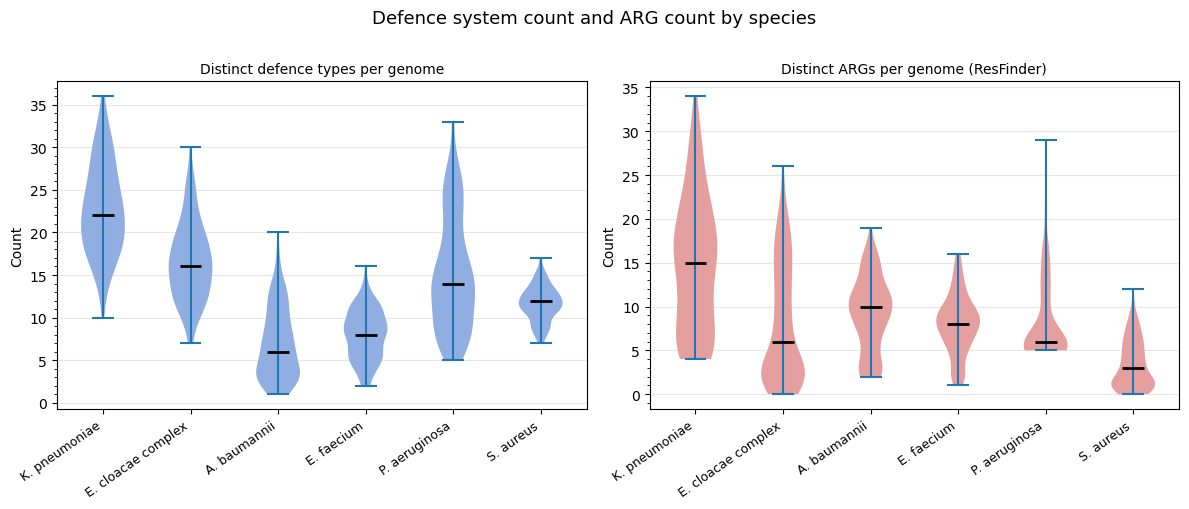

Saved: results/figures/eda/01_defence_arg_violin.png


In [3]:
# ── Violin plots: defence_system_count and arg_count_unique side by side ──────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Defence system count and ARG count by species", fontsize=13, y=1.01)

sp_labels = [SPECIES_LABELS[s] for s in SPECIES_ORDER]

for ax, var, title, colour in zip(
    axes,
    ["defence_system_count", "arg_count_unique"],
    ["Distinct defence types per genome", "Distinct ARGs per genome (ResFinder)"],
    ["#4878CF", "#D65F5F"],
):
    data_by_sp = [fm[fm["species"] == sp][var].values for sp in SPECIES_ORDER]
    parts = ax.violinplot(data_by_sp, positions=range(len(SPECIES_ORDER)),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(sp_labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_defence_arg_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/01_defence_arg_violin.png")

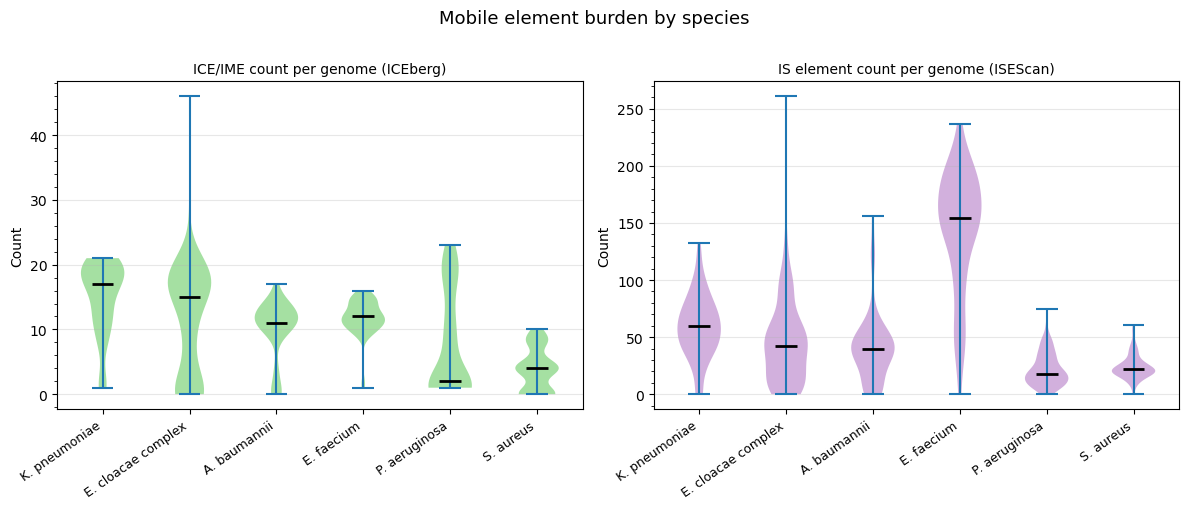

Saved: results/figures/eda/02_ime_is_violin.png


In [4]:
# ── IME and IS counts — the MGE burden landscape ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Mobile element burden by species", fontsize=13, y=1.01)

for ax, var, title, colour in zip(
    axes,
    ["ime_count_unique", "is_count_total"],
    ["ICE/IME count per genome (ICEberg)", "IS element count per genome (ISEScan)"],
    ["#6ACC65", "#B47CC7"],
):
    data_by_sp = [fm[fm["species"] == sp][var].values for sp in SPECIES_ORDER]
    parts = ax.violinplot(data_by_sp, positions=range(len(SPECIES_ORDER)),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(sp_labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_ime_is_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/02_ime_is_violin.png")

### What to read from these plots

Each violin shows the *distribution shape*, not just the mean. The thick horizontal
line inside each violin is the **median**. Wide bellies = many genomes at that count;
narrow extensions = a few outliers.

**Checklist before moving to Section 2:**
- Does A. baumannii have the lowest `defence_system_count`? (Expected from the paper)
- Does K. pneumoniae have the highest ARG burden? (Consistent with its clinical
  reputation as a high-MDR species)
- Does P. aeruginosa have the lowest IME count despite having a reasonably high
  defence count? (Suggests active defence restriction of IMEs in PA)
- Does E. faecium have anomalously high IS element counts?
  (If yes: gram-positive IS-driven MGE acquisition pathway)

Surprises from this plot become hypotheses to test in Section 3.

### Section 1 comprehension check

Answer before Section 2.

**Q1.** The median defence_system_count for A. baumannii is 6 — the lowest across all
six ESKAPE species. The median for K. pneumoniae is 22. Does this mean KP genomes are
*better protected* against phage than AB genomes? What other interpretation is consistent
with this observation?

**Q2.** E. faecium has median IS count = 154, roughly four times KP's median of 60.
But EF has lower IME count (median 12) than KP (median 17). What does the difference
between IS count and IME count tell you about the *type* of MGE activity in EF vs KP?

**Q3.** You see that defence_system_count and arg_count_unique are both highest in
K. pneumoniae. If you ran a Spearman correlation on the pooled 878-genome dataset
(all species together), would you expect a positive or negative correlation between
these two variables — and why might that pooled correlation be misleading?

## Section 2 — Defence system prevalence

### What we are looking for and why

The summary table in Section 1 told you *how many* defence systems each species
carries on average. This section reveals *which* systems they are.

**The core question:** Are defence systems species-specific (each species has its own
repertoire) or generalist (the same systems appear across all six species)?

If defence systems are species-specific, Q1 classification (predict species from
defence repertoire) will work easily. If they are generalist, the classifier must
find subtle *abundance* differences rather than presence/absence differences.

**What we plot:** A heatmap where:
- Rows = individual defence system types (274 total from DefenseFinder)
- Columns = the six ESKAPE species
- Cell colour = fraction of genomes in that species carrying that system (0–1)
- Rows are hierarchically clustered so systems with similar prevalence patterns
  cluster together — the clustering itself is biologically informative

**Three things to read from this plot:**
1. Near-universal systems (hot across all columns): present in >80% of genomes
   of every species — uninformative for Q1 but may be important for Q2 if they
   vary in count
2. Species-exclusive systems (hot in one column, cold in all others): these are
   Q1's strongest features. If a system appears in 90% of PA genomes and 0% of
   AB genomes, it nearly classifies the species on its own
3. The A. baumannii column: should be notably sparser than others, consistent
   with the published paper's finding of depauperate AB defence repertoires

In [5]:
# ── Compute per-species prevalence for each defence system type ───────────────
# dp_* columns are binary (0/1). Mean per species = fraction of genomes carrying
# each system. Result: 274 systems × 6 species matrix.

dp_cols = [c for c in fm.columns if c.startswith("dp_")]

prev = pd.DataFrame(
    {sp: fm[fm["species"] == sp][dp_cols].mean() for sp in SPECIES_ORDER},
    index=dp_cols,
)
prev.index = [c.replace("dp_", "") for c in prev.index]  # strip prefix for legibility
prev.columns = [SPECIES_LABELS[s] for s in SPECIES_ORDER]

print(f"Prevalence matrix shape: {prev.shape}  (defence types × species)")
print()

# ── How many systems are near-universal? (>80% in all 6 species) ─────────────
near_universal = prev[(prev > 0.80).all(axis=1)]
print(f"Near-universal systems (>80% in ALL 6 species): {len(near_universal)}")
if len(near_universal):
    print(near_universal.to_string())
print()

# ── How many are completely absent from AB? (prevalence = 0) ─────────────────
ab_absent = prev[prev["A. baumannii"] == 0]
print(f"Systems absent from ALL A. baumannii genomes: {len(ab_absent)}")
print()

# ── Top 10 most prevalent systems per species ─────────────────────────────────
print("Top 5 most prevalent systems per species:")
for sp_label in [SPECIES_LABELS[s] for s in SPECIES_ORDER]:
    top5 = prev[sp_label].nlargest(5)
    print(f"  {sp_label}:")
    for sys_name, val in top5.items():
        print(f"    {sys_name:<35} {val:.2f}")
    print()

Prevalence matrix shape: (274, 6)  (defence types × species)

Near-universal systems (>80% in ALL 6 species): 0

Systems absent from ALL A. baumannii genomes: 147

Top 5 most prevalent systems per species:
  K. pneumoniae:
    padloc_PDC-S07                      1.00
    padloc_PDC-S04                      0.99
    padloc_PDC-S12                      0.99
    VSPR                                0.98
    AbiE                                0.92

  E. cloacae complex:
    padloc_PDC-S07                      0.99
    VSPR                                0.99
    padloc_PDC-S12                      0.98
    PD-T4-6                             0.97
    RM_Type_I                           0.54

  A. baumannii:
    SspBCDE                             0.51
    padloc_PDC-S15                      0.37
    RM_Type_I                           0.33
    Gao_Qat                             0.32
    PD-T4-5                             0.28

  E. faecium:
    AbiE                                0.86
  

Systems with any presence: 274 of 274


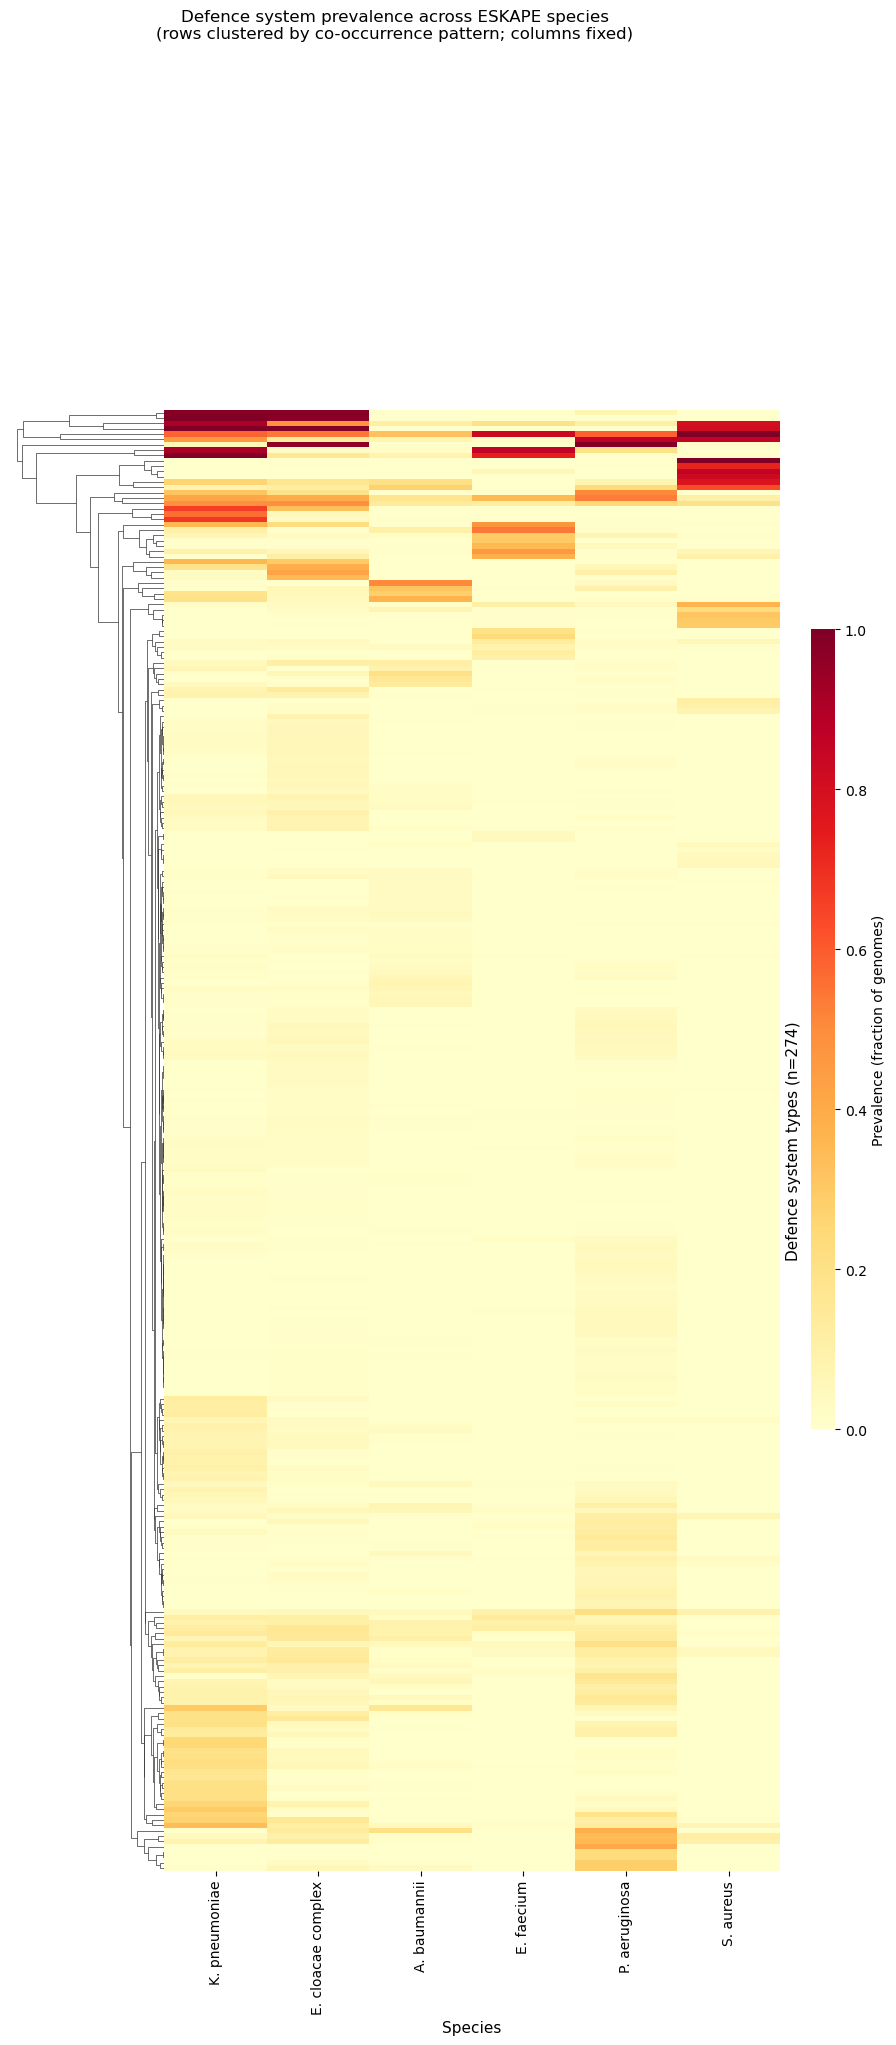

Saved: results/figures/eda/03_defence_prevalence_heatmap.png


In [6]:
# ── Full prevalence heatmap (hierarchically clustered rows) ──────────────────
# seaborn clustermap clusters both rows and columns by default.
# col_cluster=False keeps species in our fixed order.
# Row clustering groups systems with similar cross-species patterns.

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Filter: keep only systems present in ≥1 genome (prevalence > 0 in any species)
prev_nonzero = prev[(prev > 0).any(axis=1)]
print(f"Systems with any presence: {len(prev_nonzero)} of {len(prev)}")

g = sns.clustermap(
    prev_nonzero,
    col_cluster=False,         # keep species columns in SPECIES_ORDER
    row_cluster=True,          # cluster defence types by co-occurrence pattern
    cmap="YlOrRd",
    figsize=(8, 20),
    xticklabels=True,
    yticklabels=False,         # 274 labels illegible at this size
    linewidths=0,
    cbar_pos=(1.02, 0.3, 0.03, 0.4),
    cbar_kws={"label": "Prevalence (fraction of genomes)"},
)
g.ax_heatmap.set_xlabel("Species", fontsize=11)
g.ax_heatmap.set_ylabel(f"Defence system types (n={len(prev_nonzero)})", fontsize=11)
g.fig.suptitle(
    "Defence system prevalence across ESKAPE species\n"
    "(rows clustered by co-occurrence pattern; columns fixed)",
    y=1.01, fontsize=12,
)
plt.savefig(FIG_DIR / "03_defence_prevalence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/03_defence_prevalence_heatmap.png")

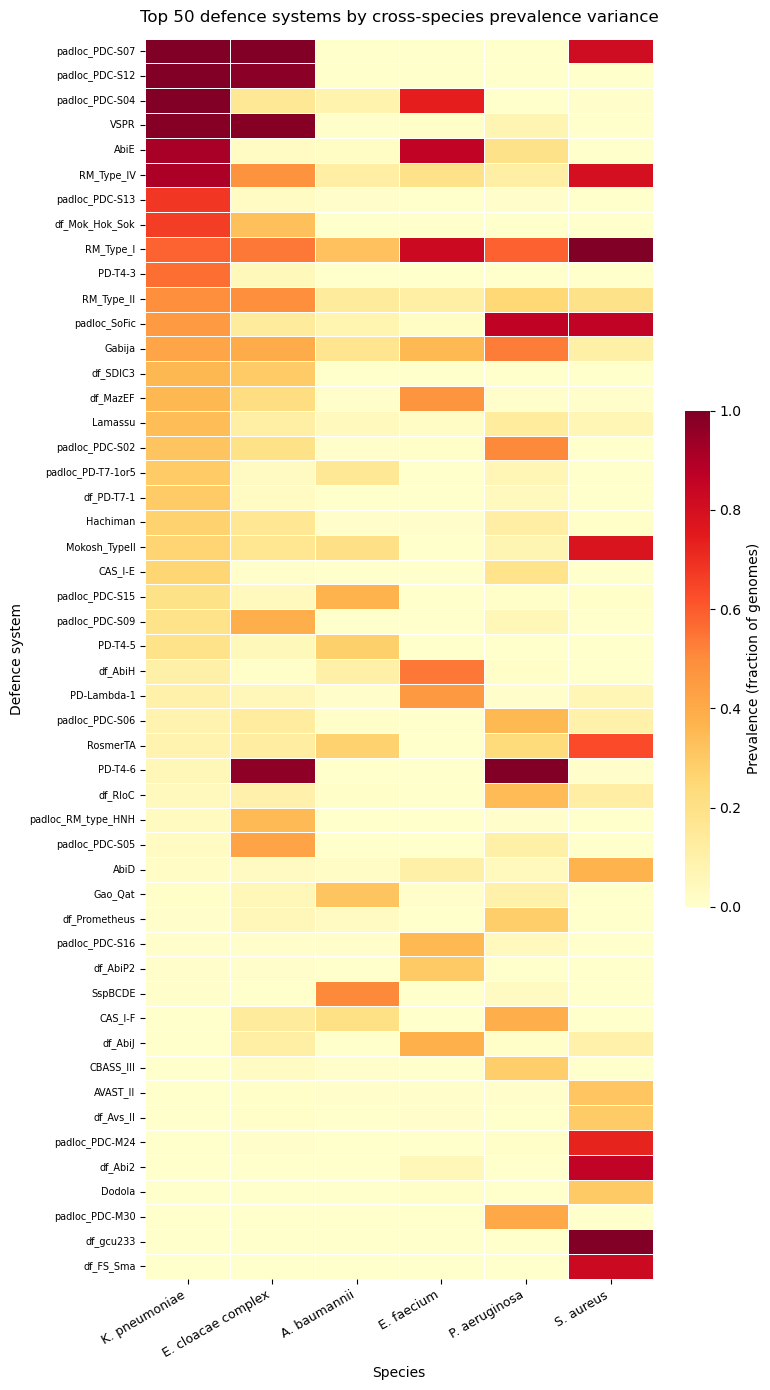

Saved: results/figures/eda/04_defence_prevalence_top50.png


In [7]:
# ── Zoom heatmap: top 50 systems by cross-species variance ────────────────────
# The full heatmap has 274 rows — most of them near-zero.
# Selecting systems with high cross-species variance shows the discriminating ones.

row_variance = prev_nonzero.var(axis=1)
top50 = prev_nonzero.loc[row_variance.nlargest(50).index]
top50 = top50.sort_values(by=list(top50.columns), ascending=False)

fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(
    top50,
    ax=ax,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.4,
    linecolor="white",
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Prevalence (fraction of genomes)", "shrink": 0.4},
)
ax.set_title(
    "Top 50 defence systems by cross-species prevalence variance",
    fontsize=12, pad=12,
)
ax.set_xlabel("Species", fontsize=10)
ax.set_ylabel("Defence system", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_defence_prevalence_top50.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/04_defence_prevalence_top50.png")

In [8]:
# ── Check prevalence of the published key systems in all 6 species ────────────
# The JAM paper identified RM systems, SspBCDE, and Gao_Qat as the main
# discriminating systems in Acinetobacter. Check if they appear in the other
# five species — if yes, cross-species generalisation is plausible.

KEY_SYSTEMS = [
    "RM_Type_I",
    "RM_Type_II",
    "RM_Type_III",
    "RM_Type_IV",
    "SspBCDE",
    "Gao_Qat",
    "Gabija",
    "Druantia",
    "Lamassu",
    "Thoeris",
    "Zorya",
    "CRISPR_Cas",
]

found_systems = [s for s in KEY_SYSTEMS if s in prev.index]
missing_systems = [s for s in KEY_SYSTEMS if s not in prev.index]

print("Published key systems — prevalence across species:")
print("=" * 90)
print(prev.loc[found_systems].to_string(float_format=lambda x: f"{x:.2f}"))
print()
if missing_systems:
    print(f"Not found in feature matrix (may be absent from all genomes): {missing_systems}")

Published key systems — prevalence across species:
             K. pneumoniae  E. cloacae complex  A. baumannii  E. faecium  P. aeruginosa  S. aureus
RM_Type_I             0.58                0.54          0.33        0.83           0.59       1.00
RM_Type_II            0.49                0.49          0.14        0.11           0.25       0.19
RM_Type_III           0.14                0.15          0.09        0.03           0.13       0.02
RM_Type_IV            0.91                0.48          0.12        0.19           0.11       0.80
SspBCDE               0.01                0.00          0.51        0.00           0.03       0.00
Gao_Qat               0.02                0.06          0.32        0.01           0.10       0.00
Gabija                0.42                0.40          0.17        0.35           0.53       0.11
Lamassu               0.34                0.11          0.05        0.02           0.13       0.07

Not found in feature matrix (may be absent from all genom

### What to read from these plots

**Full heatmap (03):** The vertical stripes of colour tell you each species'
overall defence density. A. baumannii should appear notably paler than KP.
The horizontal bands of colour are system *co-occurrence clusters* — groups of
systems that tend to appear together. These clusters often reflect shared MGE
carriers: if five systems are always on the same ICE, they will always be
co-present and will form a tight cluster.

**Top-50 zoom (04):** These are the systems with the highest cross-species
*variance* in prevalence — meaning they discriminate species most effectively.
A system that is 90% prevalent in PA but 5% in SA has high variance. These
50 systems are the ones a Q1 classifier will lean on hardest.

**Key systems table:** The published paper found RM_Type_I, SspBCDE, and
Gao_Qat as the main Acinetobacter discriminators. Their prevalence in the
other five ESKAPE species determines whether Q4 SHAP results can replicate
the published ranking. If SspBCDE appears only in AB, the SHAP comparison is
trivial. If it appears across species at variable rates, the comparison is
meaningful.

**The A. baumannii column test:** If AB is consistently the palest column in
both heatmaps, the published finding holds in the new data. If AB is not the
palest, something unexpected is in the RefSeq genome selection — investigate
before modelling.

### Section 2 comprehension check

**Q1.** The clustermap clusters rows (defence systems) but not columns (species).
Why is it correct to keep columns in a fixed order here rather than letting the
algorithm cluster them too?

**Q2.** You find that RM_Type_II has prevalence 0.88 in K. pneumoniae and 0.05
in A. baumannii. You also find that RM_Type_II is the top-ranked feature in the
Q1 Random Forest (Phase 7). A colleague says: "This just means the RF learned
that KP has RM and AB doesn't — that's phylogenetics, not defence biology. The
result is trivial." Is this critique valid? How would you respond?

**Q3.** You see a tight cluster of 8 systems that are all 0 in S. aureus and
E. faecium but present at 60–80% in the four gram-negative species. Before
looking up the system names, predict the most likely biological explanation for
this gram-stain-stratified pattern.